**Netflix Data Analysis**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

Load Data


In [2]:
df=pd.read_csv('/content/Netflix Dataset.csv')
df.head(10)

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...
5,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...
6,s7,Movie,122,Yasir Al Yasiri,"Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...",Egypt,"June 1, 2020",TV-MA,95 min,"Horror Movies, International Movies","After an awful accident, a couple admitted to ..."
7,s8,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",United States,"November 1, 2019",R,119 min,Dramas,After one of his high school students attacks ...
8,s9,Movie,706,Shravan Kumar,"Divya Dutta, Atul Kulkarni, Mohan Agashe, Anup...",India,"April 1, 2019",TV-14,118 min,"Horror Movies, International Movies","When a doctor goes missing, his psychiatrist w..."
9,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,"December 15, 2017",TV-MA,143 min,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...


In [ ]:
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB
(7789, 11)


In [3]:
#All columns and its datatype
df.dtypes

,0
Show_Id,object
Category,object
Title,object
Director,object
Cast,object
Country,object
Release_Date,object
Rating,object
Duration,object
Type,object


In [4]:
df.describe()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
count,7789,7789,7789,5401,7071,7282,7779,7782,7789,7789,7789
unique,7787,2,7787,4050,6831,681,1565,14,216,492,7769
top,s6621,Movie,The Lost Okoroshi,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,18,18,2556,118,2865,1608,334,3


# Data Preperation

In [5]:
# convert release date type into date and time
df['Release_Date']=df['Release_Date'].str.strip() # remove space
df['Release_Date']=pd.to_datetime(df['Release_Date'])
df['Release_Date'].dtypes

dtype('<M8[ns]')

Handeling missing values

In [6]:
# check null values
df.isna().sum()

,0
Show_Id,0
Category,0
Title,0
Director,2388
Cast,718
Country,507
Release_Date,10
Rating,7
Duration,0
Type,0


In [7]:
# Fill null values in Director by 'Unknown'
df['Director']=df['Director'].fillna('unknown')
display(df['Director'].isna().sum())


np.int64(0)

In [8]:
# Fill null values in Country by 'Unknown'
df['Country']=df['Country'].fillna('unknown')
display(df['Country'].isna().sum())

np.int64(0)

In [9]:
# Fill null values in Cast by 'Unknown'
df['Cast']=df['Cast'].fillna('unknown')
display(df['Cast'].isna().sum())

np.int64(0)

In [10]:
#display rows where Rating has null values
df[df['Rating'].isna()]
# Fill null values in Cast by 'Not available'
df['Rating']=df['Rating'].fillna('Not available')
display(df['Rating'].isna().sum())

np.int64(0)

In [ ]:
df[df['Release_Date'].isna()]

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
258,s259,TV Show,A Young Doctor's Notebook and Other Stories,unknown,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaT,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
549,s550,TV Show,Anthony Bourdain: Parts Unknown,unknown,Anthony Bourdain,United States,NaT,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
2263,s2264,TV Show,Frasier,unknown,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaT,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
2288,s2289,TV Show,Friends,unknown,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaT,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
2555,s2556,TV Show,Gunslinger Girl,unknown,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaT,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
3374,s3375,TV Show,Kikoriki,unknown,Igor Dmitriev,unknown,NaT,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
3492,s3493,TV Show,La Familia P. Luche,unknown,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaT,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
3946,s3947,TV Show,Maron,unknown,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaT,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
5138,s5138,TV Show,Red vs. Blue,unknown,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaT,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
6066,s6066,TV Show,The Adventures of Figaro Pho,unknown,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaT,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


In [11]:
# check null values
df.isna().sum()

,0
Show_Id,0
Category,0
Title,0
Director,0
Cast,0
Country,0
Release_Date,10
Rating,0
Duration,0
Type,0


# Handeling Duplicates

In [12]:
# find duplicate columns
df.loc[df.duplicated()]

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
6300,s684,Movie,Backfire,Dave Patten,"Black Deniro, Byron ""Squally"" Vinson, Dominic ...",United States,2019-04-05,TV-MA,97 min,"Dramas, Independent Movies, Thrillers",When two would-be robbers accidentally kill a ...
6622,s6621,Movie,The Lost Okoroshi,Abba T. Makama,"Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...",Nigeria,2020-09-04,TV-MA,94 min,"Comedies, Dramas, Independent Movies",A disillusioned security guard transforms into...


In [13]:
df[df.duplicated(subset=['Show_Id'], keep=False)] #  show duplicates with original one


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
683,s684,Movie,Backfire,Dave Patten,"Black Deniro, Byron ""Squally"" Vinson, Dominic ...",United States,2019-04-05,TV-MA,97 min,"Dramas, Independent Movies, Thrillers",When two would-be robbers accidentally kill a ...
4839,s6621,Movie,The Lost Okoroshi,Abba T. Makama,"Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...",Nigeria,2020-09-04,TV-MA,94 min,"Comedies, Dramas, Independent Movies",A disillusioned security guard transforms into...
6300,s684,Movie,Backfire,Dave Patten,"Black Deniro, Byron ""Squally"" Vinson, Dominic ...",United States,2019-04-05,TV-MA,97 min,"Dramas, Independent Movies, Thrillers",When two would-be robbers accidentally kill a ...
6622,s6621,Movie,The Lost Okoroshi,Abba T. Makama,"Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...",Nigeria,2020-09-04,TV-MA,94 min,"Comedies, Dramas, Independent Movies",A disillusioned security guard transforms into...


In [14]:
# remove extraspace and convert into a title

df['Title'] = df['Title'].str.replace('\s+', ' ', regex=True).str.strip().str.title()

#find duplicates column wise

df[df.duplicated(subset=['Title'], keep=False)]




<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3662704202.py:3: SyntaxWarning: invalid escape sequence '\s'
  df['Title'] = df['Title'].str.replace('\s+', ' ', regex=True).str.strip().str.title()


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
683,s684,Movie,Backfire,Dave Patten,"Black Deniro, Byron ""Squally"" Vinson, Dominic ...",United States,2019-04-05,TV-MA,97 min,"Dramas, Independent Movies, Thrillers",When two would-be robbers accidentally kill a ...
1485,s1486,Movie,Consequences,Ozan Açıktan,"Nehir Erdoğan, Tardu Flordun, İlker Kaleli, Se...",Turkey,2019-10-25,TV-MA,106 min,"Dramas, International Movies, Thrillers",Secrets bubble to the surface after a sensual ...
1486,s1487,Movie,Consequences,Ozan Açıktan,"Nehir Erdoğan, Tardu Flordun, İlker Kaleli, Se...",Turkey,2019-10-25,TV-MA,106 min,"Dramas, International Movies, Thrillers",Secrets bubble to the surface after a sensual ...
4839,s6621,Movie,The Lost Okoroshi,Abba T. Makama,"Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...",Nigeria,2020-09-04,TV-MA,94 min,"Comedies, Dramas, Independent Movies",A disillusioned security guard transforms into...
6300,s684,Movie,Backfire,Dave Patten,"Black Deniro, Byron ""Squally"" Vinson, Dominic ...",United States,2019-04-05,TV-MA,97 min,"Dramas, Independent Movies, Thrillers",When two would-be robbers accidentally kill a ...
6622,s6621,Movie,The Lost Okoroshi,Abba T. Makama,"Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...",Nigeria,2020-09-04,TV-MA,94 min,"Comedies, Dramas, Independent Movies",A disillusioned security guard transforms into...


In [15]:
#drop duplicate based on column
df=df.drop_duplicates(subset=['Title'], keep='first')

#check final duplicate
df[df.duplicated(subset=['Title'], keep=False)]


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description


In [16]:
# quarry to check a
df[df['Title']=='The Lost Okoroshi']

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
4839,s6621,Movie,The Lost Okoroshi,Abba T. Makama,"Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...",Nigeria,2020-09-04,TV-MA,94 min,"Comedies, Dramas, Independent Movies",A disillusioned security guard transforms into...


# Feature Understanding

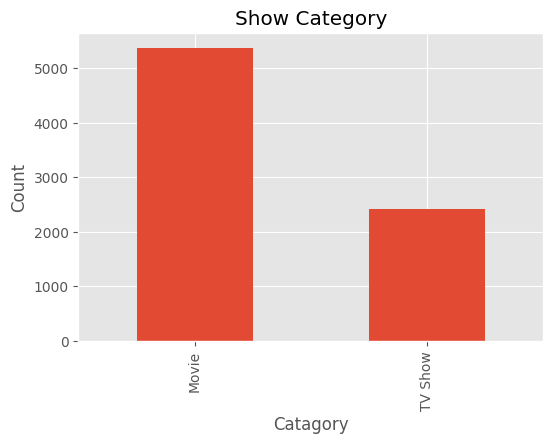

In [41]:
# Count of Movies vs TV Shows
ax = df['Category'].value_counts().plot(kind='bar', title='Show Category', figsize=(6, 4))
ax.set_xlabel('Catagory')
ax.set_ylabel('Count')
plt.show()


In [18]:
# remove extraspace and convert into a title

df['Director'] = df['Director'].str.replace('\s+', ' ', regex=True).str.strip()

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-952143350.py:3: SyntaxWarning: invalid escape sequence '\s'
  df['Director'] = df['Director'].str.replace('\s+', ' ', regex=True).str.strip()


Director
unknown                   2388
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
                          ... 
John Trengove                1
Jonathan Helpert             1
Jacob Schwab                 1
Serge Ou                     1
Eugenio Derbez               1
Name: count, Length: 4051, dtype: int64

................................................................



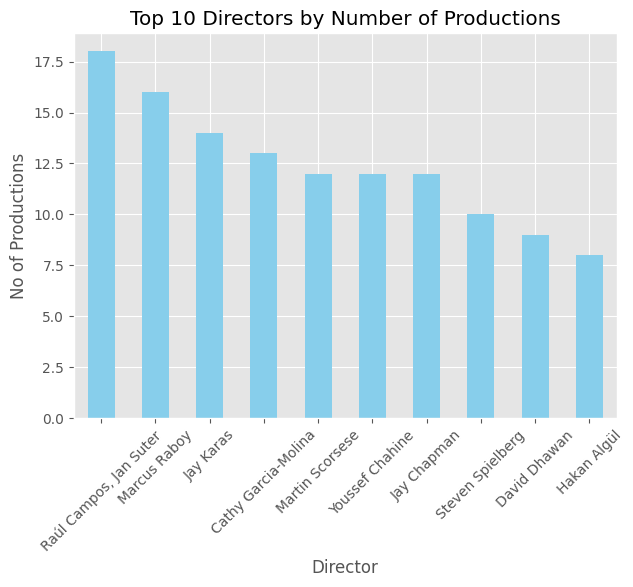

In [40]:
df_clean=df[df['Director']!='unknown']
print(df['Director'].value_counts())
print("\n................................................................\n")

df_clean['Director'].value_counts().head(10).plot(
    kind='bar',
    figsize=(7, 5),       # chart size
    color='skyblue',
    title='Top 10 Directors by Number of Productions'
)

plt.xlabel('Director')
plt.ylabel('No of Productions')
plt.xticks(rotation=45)   # rotate labels to fit nicely
plt.show()


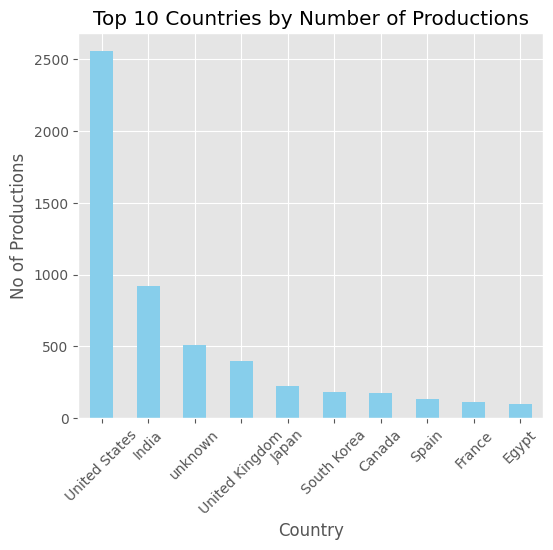

In [39]:
# Top Countries
df['Country'].value_counts().head(10).plot(
    kind='bar',
    figsize=(6, 5),
    color='skyblue',
    title='Top 10 Countries by Number of Productions'
)

plt.xlabel('Country')
plt.ylabel('No of Productions')
plt.xticks(rotation=45)   # rotate labels
plt.show()

In [21]:
# Dataset span (years)
df['Release_Date'].agg(['min', 'max'])


,Release_Date
min,2008-01-01
max,2021-01-16


# Data Analysis & Visualizations

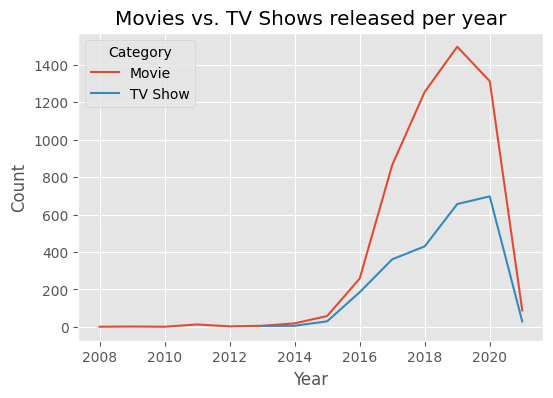

In [38]:
# Line Chart – Movies vs. TV Shows released per year
df.groupby(df['Release_Date'].dt.year)['Category'].value_counts().unstack().plot(kind='line', figsize=(6, 4))
plt.title('Movies vs. TV Shows released per year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()



Bar Chart – Top 10 Genres

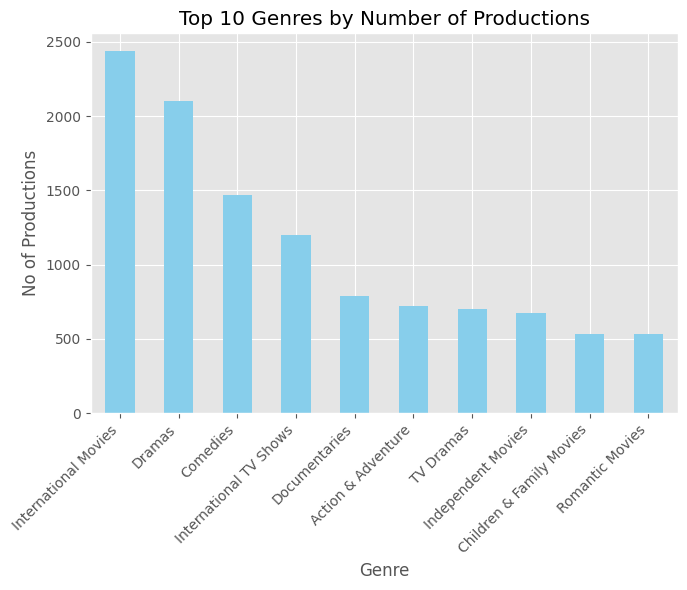

In [37]:
# Extract genres from the 'Type' column and count occurrences
genres = df['Type'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

# Bar Chart – Top 10 Genres
top_genres.plot(
    kind='bar',
    figsize=(7, 6),
    color='skyblue',
    title='Top 10 Genres by Number of Productions'
)

plt.xlabel('Genre')
plt.ylabel('No of Productions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

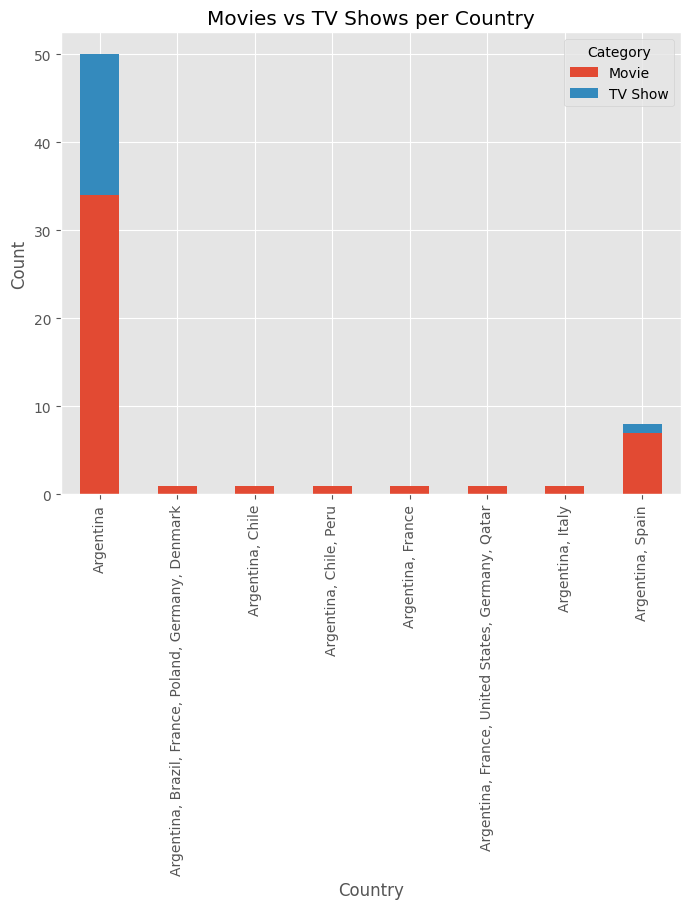

In [36]:
#Stacked Bar Chart – Movies vs TV Shows per Country
df.groupby('Country')['Category'].value_counts().head(10).unstack().plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Movies vs TV Shows per Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

In [29]:
#Choropleth Map – Country-wise Content

import plotly.express as px

# Prepare data for choropleth map
country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

# Remove 'unknown' country
country_counts = country_counts[country_counts['Country'] != 'unknown']

# Create choropleth map
fig = px.choropleth(country_counts,
                    locations="Country",
                    locationmode="country names",
                    color="Count",
                    hover_name="Country",
                    title="Country-wise Content Distribution on Netflix",
                    color_continuous_scale=px.colors.sequential.Plasma)
fig.show()

/tmp/ipython-input-1845598703.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




Generated plot: top_15_ratings.png


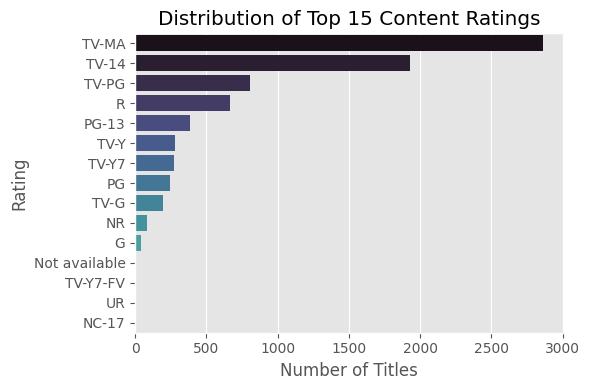

In [34]:
# Get the top 15 ratings
top_ratings = df['Rating'].value_counts().head(15)

plt.figure(figsize=(6, 4))
sns.barplot(x=top_ratings.values, y=top_ratings.index, palette='mako')
plt.title('Distribution of Top 15 Content Ratings')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('top_15_ratings.png')

print("Generated plot: top_15_ratings.png")